In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [98]:
def process_imu_data(filepath, alpha=0.98, max_rows=None):
    """
    Load IMU data and calculate accelerometer-only, gyro-only,
    and complementary-filter roll and pitch estimates.
    """

    df = pd.read_csv(filepath)

    if max_rows is not None:
        df = df.iloc[:max_rows].copy()

    # Start time at zero
    df["time_s"] = (
        df["timestamp_ms"] - df["timestamp_ms"].iloc[0]
    ) / 1000.0

    # Time elapsed since previous sample
    dt = np.diff(
        df["time_s"],
        prepend=df["time_s"].iloc[0]
    )

    df["dt_s"] = dt

    # Accelerometer-only orientation
    df["roll_acc_deg"] = np.degrees(
        np.arctan2(
            df["ay_calibrated_g"],
            df["az_calibrated_g"]
        )
    )

    df["pitch_acc_deg"] = np.degrees(
        np.arctan2(
            -df["ax_calibrated_g"],
            np.sqrt(
                df["ay_calibrated_g"]**2
                + df["az_calibrated_g"]**2
            )
        )
    )

    # Gyroscope-only orientation
    df["roll_gyro_deg"] = (
        df["roll_acc_deg"].iloc[0]
        + np.cumsum(df["gx_dps"] * df["dt_s"])
    )

    df["pitch_gyro_deg"] = (
        df["pitch_acc_deg"].iloc[0]
        + np.cumsum(df["gy_dps"] * df["dt_s"])
    )

    # Complementary-filter orientation
    roll_comp = np.zeros(len(df))
    pitch_comp = np.zeros(len(df))

    roll_comp[0] = df["roll_acc_deg"].iloc[0]
    pitch_comp[0] = df["pitch_acc_deg"].iloc[0]

    for k in range(1, len(df)):
        roll_prediction = (
            roll_comp[k - 1]
            + df["gx_dps"].iloc[k] * df["dt_s"].iloc[k]
        )

        pitch_prediction = (
            pitch_comp[k - 1]
            + df["gy_dps"].iloc[k] * df["dt_s"].iloc[k]
        )

        roll_comp[k] = (
            alpha * roll_prediction
            + (1 - alpha) * df["roll_acc_deg"].iloc[k]
        )

        pitch_comp[k] = (
            alpha * pitch_prediction
            + (1 - alpha) * df["pitch_acc_deg"].iloc[k]
        )

    df["roll_comp_deg"] = roll_comp
    df["pitch_comp_deg"] = pitch_comp

    return df

In [99]:
def plot_estimate_comparison(df, experiment_name):
    plt.figure(figsize=(12, 5))

    plt.plot(
        df["time_s"],
        df["roll_acc_deg"],
        label="Accelerometer roll"
    )

    plt.plot(
        df["time_s"],
        df["roll_gyro_deg"],
        label="Gyro roll"
    )

    plt.plot(
        df["time_s"],
        df["roll_comp_deg"],
        label="Complementary roll"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Roll angle (degrees)")
    plt.title(f"{experiment_name}: Roll Estimate Comparison")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.plot(
        df["time_s"],
        df["pitch_acc_deg"],
        label="Accelerometer pitch"
    )

    plt.plot(
        df["time_s"],
        df["pitch_gyro_deg"],
        label="Gyro pitch"
    )

    plt.plot(
        df["time_s"],
        df["pitch_comp_deg"],
        label="Complementary pitch"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Pitch angle (degrees)")
    plt.title(f"{experiment_name}: Pitch Estimate Comparison")
    plt.legend()
    plt.grid()
    plt.show()

In [100]:
static_df = process_imu_data(
    "Roll Pitch/Roll Pitch Data.csv",
    alpha=0.98,
    max_rows=8001
)

shake_df = process_imu_data(
    "Roll Pitch/Shake Data.csv",
    alpha=0.98
)

static_df = process_imu_data(
    "Roll Pitch/Roll Pitch Data.csv",
    alpha=0.98,
    max_rows=8001
)

hold_df = process_imu_data(
    "Roll Pitch/Long Hold.csv",
    alpha=0.98
)

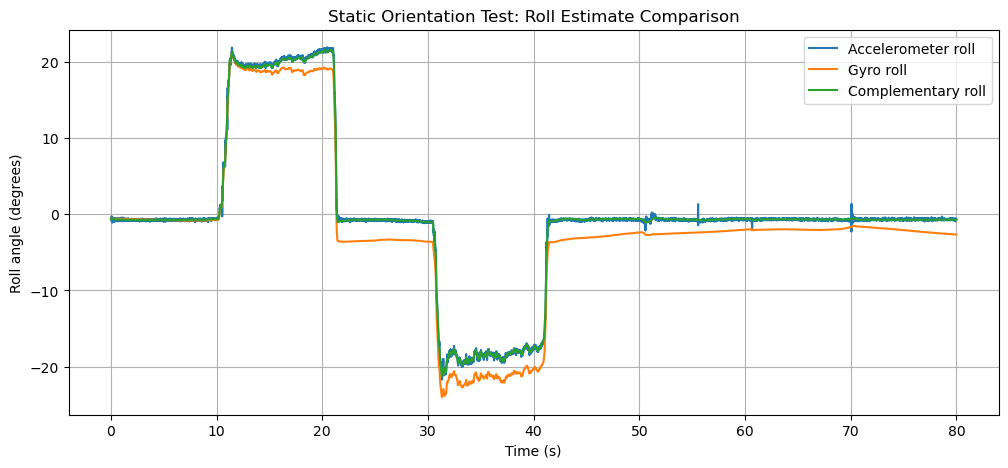

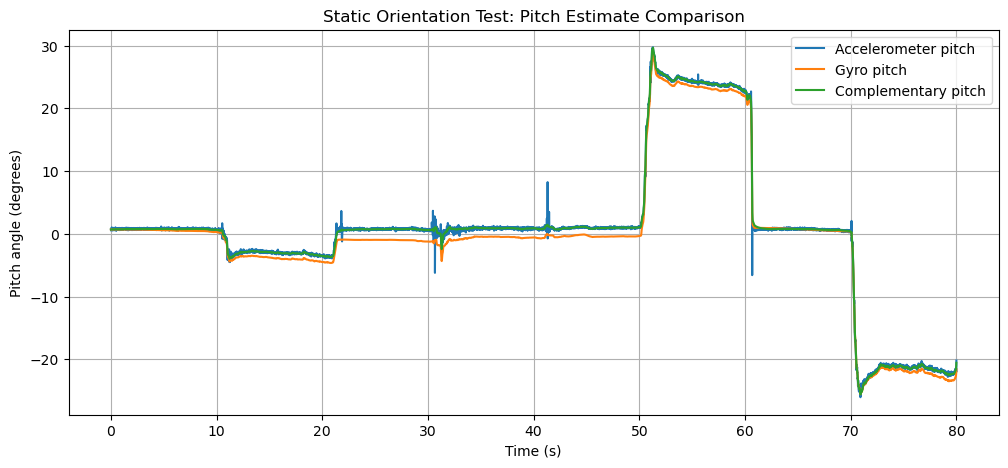

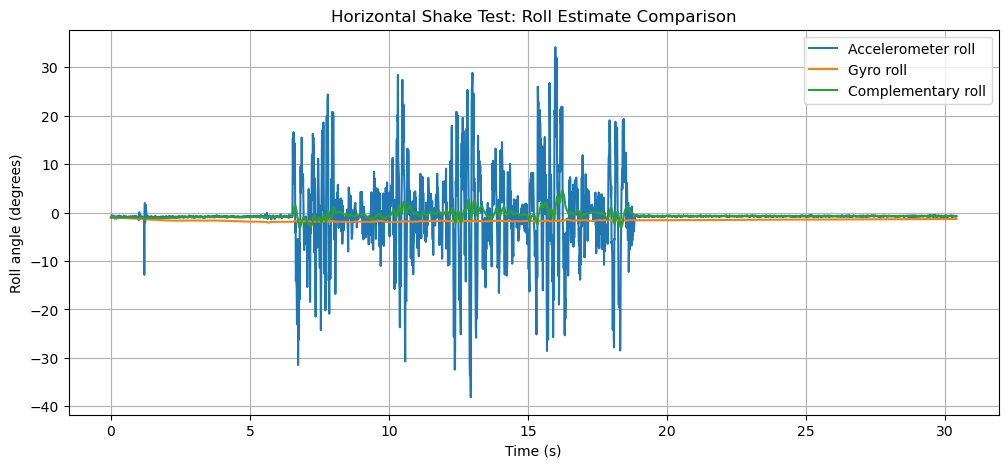

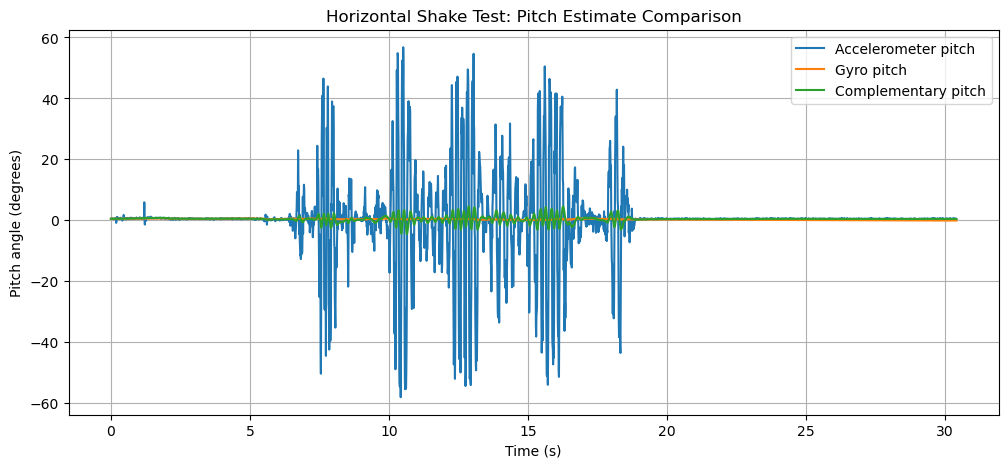

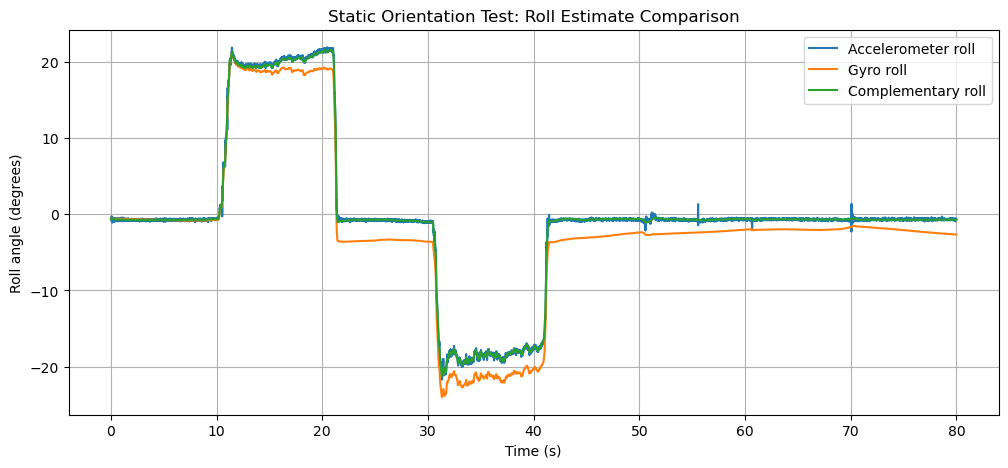

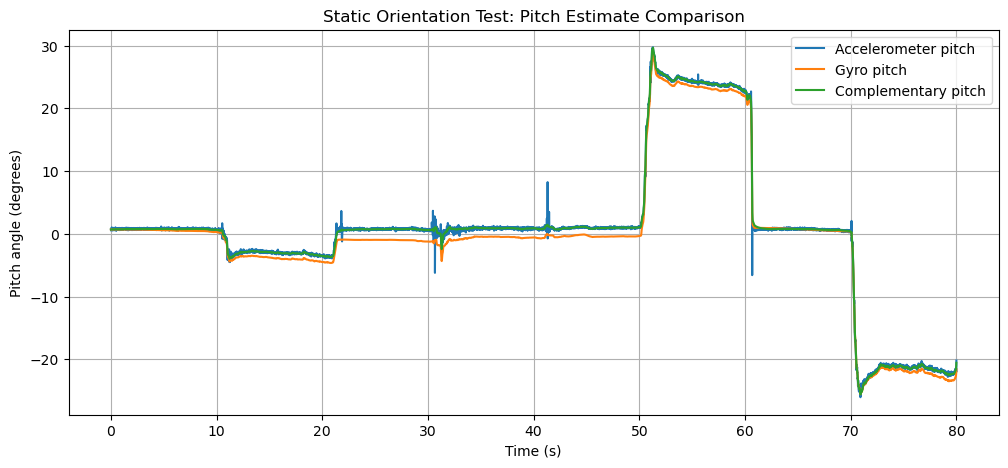

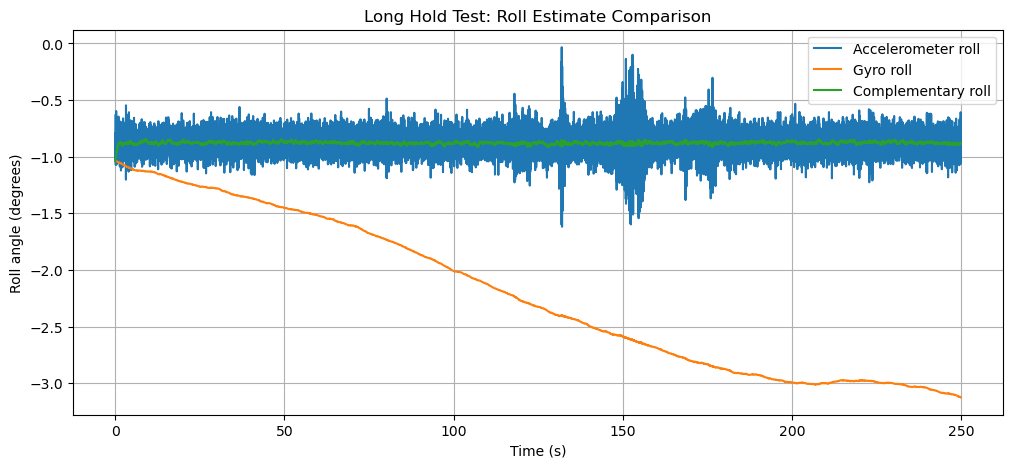

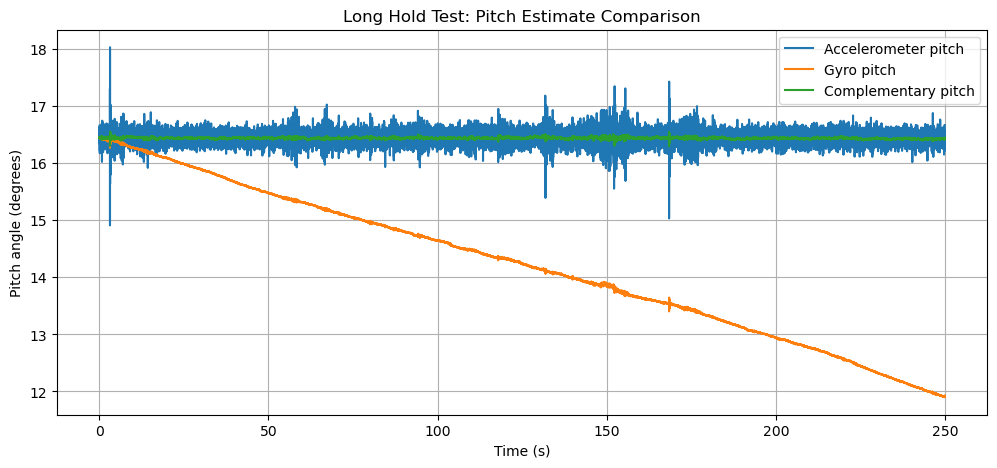

In [101]:
plot_estimate_comparison(
    static_df,
    "Static Orientation Test"
)

plot_estimate_comparison(
    shake_df,
    "Horizontal Shake Test"
)

plot_estimate_comparison(
    static_df,
    "Static Orientation Test"
)

plot_estimate_comparison(
    hold_df,
    "Long Hold Test"
)